# Sesión 5 mejorada — Procesamiento de Lenguaje Natural (NLP)

**Curso:** Fundamentos de Programación para IA Generativa Aplicada  
**Programa:** Especialización en IA Generativa aplicada a CCSS y Gestión Pública  

## Propósito de esta sesión

Esta versión mejorada de la sesión 5 reproduce y expande el notebook original de NLP.  
El objetivo ya no es solo ilustrar técnicas básicas de procesamiento de texto, sino hacerlo de manera: reproducible, auditable, metodológicamente ordenada, y con una transición explícita hacia textos administrativos reales. En esta sesión trabajaremos con tres niveles:

1. **Nivel introductorio:** conceptos y operaciones básicas de NLP.
2. **Nivel aplicado:** uso de archivos reales de convocatorias 2022 del portal CONOSCE/OECE.
3. **Nivel preparatorio:** construcción de una base conceptual y técnica para la Tarea 2.

## Idea metodológica

En ciencias sociales aplicadas, los textos no son solo cadenas de caracteres.  
Son inscripciones institucionales, descripciones de procedimientos, objetos de contratación, decisiones administrativas y huellas documentales de relaciones sociales y estatales. Por ello, el NLP aquí no será tratado únicamente como técnica computacional, sino como una forma de representar, ordenar y explorar regularidades en textos administrativos.

## Secuencia de trabajo

**archivo bruto → auditoría → limpieza → corpus → representación → exploración → modelado → exportación**

In [2]:
# ============================================================
# SESIÓN 5 MEJORADA — CONFIGURACIÓN DEL ENTORNO
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import pandas as pd
import numpy as np
import re
import unicodedata
from collections import Counter

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 200)

# Rutas principales
RUTA_BASE = Path("/content/drive/MyDrive/IA Generativa para CCSS/Base de datos")
RUTA_INSUMOS = RUTA_BASE / "Insumos"
RUTA_RESULTADOS = RUTA_BASE / "Resultados" / "Sesion_5_NLP_mejorada"

# Subcarpetas de resultados
RUTA_TABLAS = RUTA_RESULTADOS / "tablas"
RUTA_FIGURAS = RUTA_RESULTADOS / "figuras"
RUTA_MODELOS = RUTA_RESULTADOS / "modelos"
RUTA_AUDITORIA = RUTA_RESULTADOS / "auditoria"

for ruta in [RUTA_RESULTADOS, RUTA_TABLAS, RUTA_FIGURAS, RUTA_MODELOS, RUTA_AUDITORIA]:
    ruta.mkdir(parents=True, exist_ok=True)

print("RUTA_BASE      :", RUTA_BASE)
print("RUTA_INSUMOS   :", RUTA_INSUMOS)
print("RUTA_RESULTADOS:", RUTA_RESULTADOS)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
RUTA_BASE      : /content/drive/MyDrive/IA Generativa para CCSS/Base de datos
RUTA_INSUMOS   : /content/drive/MyDrive/IA Generativa para CCSS/Base de datos/Insumos
RUTA_RESULTADOS: /content/drive/MyDrive/IA Generativa para CCSS/Base de datos/Resultados/Sesion_5_NLP_mejorada


In [3]:
# ============================================================
# INVENTARIO Y FUNCIONES AUXILIARES
# ============================================================

def normalizar_texto(texto: str) -> str:
    texto = str(texto).strip().lower()
    texto = "".join(
        ch for ch in unicodedata.normalize("NFD", texto)
        if unicodedata.category(ch) != "Mn"
    )
    texto = re.sub(r"[^a-z0-9._-]+", "_", texto)
    return texto

def normalizar_columna(col: str) -> str:
    col = str(col).strip().lower()
    col = "".join(
        ch for ch in unicodedata.normalize("NFD", col)
        if unicodedata.category(ch) != "Mn"
    )
    col = re.sub(r"[^a-z0-9]+", "_", col)
    col = re.sub(r"_+", "_", col).strip("_")
    return col

def buscar_archivo_por_fragmentos(directorio: Path, fragmentos: list[str]):
    candidatos = []
    for archivo in directorio.iterdir():
        if archivo.is_file():
            nombre = normalizar_texto(archivo.name)
            if all(normalizar_texto(f) in nombre for f in fragmentos):
                candidatos.append(archivo)
    return sorted(candidatos)[0] if candidatos else None

def auditar_dataframe(df: pd.DataFrame, nombre: str) -> pd.DataFrame:
    resumen = pd.DataFrame({
        "variable": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "n_missing": df.isna().sum().values,
        "pct_missing": (df.isna().mean() * 100).round(2).values,
        "n_unicos": df.nunique(dropna=True).values
    })
    print(f"{nombre}: {df.shape[0]:,} filas × {df.shape[1]:,} columnas")
    return resumen.sort_values(["pct_missing", "variable"], ascending=[False, True]).reset_index(drop=True)

# Inventario
archivos = sorted([p for p in RUTA_INSUMOS.iterdir() if p.is_file()])

print(f"Archivos detectados en Insumos: {len(archivos)}")
for a in archivos:
    print("-", a.name)

Archivos detectados en Insumos: 4
- CONOSCE_CONVOCATORIAS2022_0.xlsx
- CONOSCE_CONVOCATORIAS_CD2022_0.xlsx
- CONOSCE_CONVOCATORIAS_SIE2022_0.xlsx
- Diccionario.xlsx


In [4]:
# ============================================================
# RESOLUCIÓN DE ARCHIVOS CLAVE
# ============================================================

ARCHIVOS_OBJETIVO = {
    "convocatorias_2022_todos": ["conosce", "convocatorias2022"],
    "convocatorias_2022_sie": ["conosce", "convocatorias", "sie2022"],
    "convocatorias_2022_cd": ["conosce", "convocatorias", "cd2022"],
    "diccionario": ["diccionario"]
}

rutas = {}
for nombre, fragmentos in ARCHIVOS_OBJETIVO.items():
    rutas[nombre] = buscar_archivo_por_fragmentos(RUTA_INSUMOS, fragmentos)

df_rutas = pd.DataFrame({
    "objeto": list(rutas.keys()),
    "ruta": [str(v) if v else None for v in rutas.values()],
    "estado": ["OK" if v else "FALTA" for v in rutas.values()]
})

display(df_rutas)

if (df_rutas["estado"] == "FALTA").any():
    raise FileNotFoundError(
        "Faltan archivos en la carpeta Insumos. Revisa nombres y ubicación."
    )

RUTA_CONV_2022 = rutas["convocatorias_2022_todos"]
RUTA_SIE_2022 = rutas["convocatorias_2022_sie"]
RUTA_CD_2022 = rutas["convocatorias_2022_cd"]
RUTA_DICCIONARIO = rutas["diccionario"]

,objeto,ruta,estado
0,convocatorias_2022_todos,/content/drive/MyDrive/IA Generativa para CCSS/Base de datos/Insumos/CONOSCE_CONVOCATORIAS2022_0.xlsx,OK
1,convocatorias_2022_sie,/content/drive/MyDrive/IA Generativa para CCSS/Base de datos/Insumos/CONOSCE_CONVOCATORIAS_SIE2022_0.xlsx,OK
2,convocatorias_2022_cd,/content/drive/MyDrive/IA Generativa para CCSS/Base de datos/Insumos/CONOSCE_CONVOCATORIAS_CD2022_0.xlsx,OK
3,diccionario,/content/drive/MyDrive/IA Generativa para CCSS/Base de datos/Insumos/Diccionario.xlsx,OK


In [5]:
# ============================================================
# LECTURA DEL DICCIONARIO DE DATOS
# ============================================================

dic_raw = pd.read_excel(RUTA_DICCIONARIO, sheet_name="Convocatoria Diccionario", header=None)
display(dic_raw.head(15))

# Convertir el diccionario a formato más usable
dic = dic_raw.iloc[3:].copy()
dic.columns = ["variable", "descripcion", "tipo_dato", "tamano", "recurso_relacionado", "informacion_adicional"]
dic = dic[dic["variable"].notna()].copy()
dic["variable"] = dic["variable"].astype(str).str.strip()
dic = dic.reset_index(drop=True)

display(dic.head(20))

dic.to_csv(RUTA_AUDITORIA / "s5_diccionario_convocatoria_limpio.csv", index=False, encoding="utf-8")
print("Diccionario exportado.")

,0,1,2,3,4,5
0,NaN,NaN,NaN,NaN,NaN,NaN
1,Nombre del Dataset:,DATOS DE LA CONVOCATORIA O INVITACIÓN DE LAS ENTIDADES – [ORGANISMO ESPECIALIZADO PARA LAS CONTRATACIONES PÚBLICAS EFICIENTES - OECE],NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN
3,Variable,Descripción,Tipo de Dato,Tamaño,Recurso Relacionado,Información Adicional
4,CODIGOENTIDAD,Código de la entidad.,Texto,6,NaN,NaN
5,ENTIDAD_RUC,RUC de la entidad.,Texto,11,NaN,NaN
6,ENTIDAD,Nombre de la entidad.,Texto,250,NaN,NaN
7,TIPOENTIDAD,"Tipo de la entidad, puede ser gobierno local, regional, entre otros.",Texto,50,NaN,NaN
8,CODIGOCONVOCATORIA,Código de la convocatoria,Número,10,NaN,NaN
9,DESCRIPCION_PROCESO,Descripción del proceso o procedimiento de selección.,Texto,600,NaN,NaN


,variable,descripcion,tipo_dato,tamano,recurso_relacionado,informacion_adicional
0,Variable,Descripción,Tipo de Dato,Tamaño,Recurso Relacionado,Información Adicional
1,CODIGOENTIDAD,Código de la entidad.,Texto,6,NaN,NaN
2,ENTIDAD_RUC,RUC de la entidad.,Texto,11,NaN,NaN
3,ENTIDAD,Nombre de la entidad.,Texto,250,NaN,NaN
4,TIPOENTIDAD,"Tipo de la entidad, puede ser gobierno local, regional, entre otros.",Texto,50,NaN,NaN
5,CODIGOCONVOCATORIA,Código de la convocatoria,Número,10,NaN,NaN
6,DESCRIPCION_PROCESO,Descripción del proceso o procedimiento de selección.,Texto,600,NaN,NaN
7,PROCESO,Nomenclatura del proceso o procedimiento de selección.,Texto,50,NaN,NaN
8,TIPO_COMPRA,Tipo de compra: Puede ser: por la Entidad. Por Encargo o Compra Corporativa.,Texto,50,NaN,NaN
9,OBJETOCONTRACTUAL,"Objeto (bien, servicio, obra, consultoría de obra).",Texto,50,NaN,NaN


Diccionario exportado.


In [6]:
# ============================================================
# CARGA DE ARCHIVOS 2022
# ============================================================

def cargar_convocatorias(path: Path, fuente: str) -> pd.DataFrame:
    df = pd.read_excel(path, sheet_name="CONOSCE")
    df.columns = [normalizar_columna(c) for c in df.columns]
    df["fuente_archivo"] = fuente
    return df

df_conv_2022 = cargar_convocatorias(RUTA_CONV_2022, "todos_los_procesos")
df_sie_2022 = cargar_convocatorias(RUTA_SIE_2022, "solo_sie")
df_cd_2022 = cargar_convocatorias(RUTA_CD_2022, "solo_cd")

print("Dimensiones:")
print("General 2022:", df_conv_2022.shape)
print("SIE 2022    :", df_sie_2022.shape)
print("CD 2022     :", df_cd_2022.shape)

display(df_conv_2022.head(3))
display(df_sie_2022.head(3))
display(df_cd_2022.head(3))

Dimensiones:
General 2022: (67889, 29)
SIE 2022    : (8046, 29)
CD 2022     : (5465, 29)


,codigoentidad,entidad_ruc,entidad,tipoentidad,codigoconvocatoria,descripcion_proceso,proceso,tipocompra,objetocontractual,sector_nivel_de_gobierno,sistema_contratacion,tipoprocesoseleccion,montoreferencial,n_item,descripcion_item,unidad_medida,estadoitem,paquete,codigoitem,itemcubso,monto_referencial_item,moneda,departamento_item,provincia_item,distrito_item,fecha_convocatoria,fechaintegracionbases,fechapresentacionpropuesta,fuente_archivo
0,724,20200367376,MUNICIPALIDAD PROVINCIAL DE SANTA CRUZ,GOBIERNO LOCAL,863808,"CONTRATACIÓN PARA LA EJECUCIÓN DE LA OBRA: MEJORAMIENTO DEL CAMINO VECINAL R-59 ENTRE LAS LOCALIDADES DE PULAN, LA ACHIRA Y LITCAN DEL DISTRITO DE PULAN - PROVINCIA DE SANTA CRUZ - DEPARTAMENTO ...",AS-SM-6-2022-MPSC/CS-2,Por la Entidad,Obra,GOBIERNO LOCAL,Precios unitarios,Adjudicación Simplificada,11672602.96,1,"CONTRATACI¿N PARA LA EJECUCI¿N DE LA OBRA: MEJORAMIENTO DEL CAMINO VECINAL R-59 ENTRE LAS LOCALIDADES DE PULAN, LA ACHIRA Y LITCAN DEL DISTRITO DE PULAN - PROVINCIA DE SANTA CRUZ - DEPARTAMENTO ...",Servicio,Contratado,NO,360065.0,CONSTRUCCION DE CAMINO VECINAL,11672602.96,Soles,CAJAMARCA,SANTA CRUZ,SANTA CRUZ,2022-11-14,2022-11-22,2022-11-25,todos_los_procesos
1,10216,20171604355,HOSPITAL SANTA ROSA,GOBIERNO NACIONAL,837112,"ADQUISICIÓN DE EQUIPO MICROSCOPIO QUIRÚRGICO OFTALMOLÓGICO PARA EL HOSPITAL DE APOYO SANTA ROSA, LIMA, PUEBLO LIBRE, EN EL MARCO DEL IOARR CIU 2523590",LP-SM-3-2022-HSR-1,Por la Entidad,Bien,SALUD,Suma alzada,Licitación Pública,468755.17,1,MICROSCOPIO QUIR¿RGICO OFTALMOL¿GICO,Unidad,Contratado,SI,NaN,NaN,468755.17,Soles,LIMA,LIMA,PUEBLO LIBRE,2022-08-08,2022-09-02,2022-09-13,todos_los_procesos
2,1841,20227623544,MUNICIPALIDAD DISTRITAL DE CIUDAD NUEVA,GOBIERNO LOCAL,790601,ADQUISICIÓN DE LADRILLOS PARA LA OBRA CREACIÓN DE LOS SERVICIOS FUNERARIOS Y DE SEPULTURA EN EL SECTOR VIII ALTO CIUDAD NUEVA DISTRITO DE CIUDAD NUEVA - PROVINCIA DE TACNA - DEPARTAMENTO DE TACNA.,AS-SM-3-2022-CS-MDCN-T-2,Por la Entidad,Bien,GOBIERNO LOCAL,Suma alzada,Adjudicación Simplificada,133459.87,1,"ADQUISICI¿N DE LADRILLO DE ARCILLA DE 10X14X24CM, LADRILLO PARA TECHO DE 15X30X30CM y LADRILLO PASTELERO 24X24X3CM PARA LA OBRA CREACI¿N DE LOS SERVICIOS FUNERARIOS Y DE SEPULTURA EN EL SECTOR VII...",Unidad,Contratado,NO,147581.0,LADRILLO DE ARCILLA KING KONG DE 10 cm X 14 cm X 24 cm,133459.87,Soles,TACNA,TACNA,CIUDAD NUEVA,2022-03-28,2022-04-01,2022-04-06,todos_los_procesos


,codigoentidad,entidad_ruc,entidad,tipoentidad,codigoconvocatoria,descripcion_proceso,proceso,tipocompra,objetocontractual,sector_nivel_de_gobierno,sistema_contratacion,tipoprocesoseleccion,montoreferencial,n_item,descripcion_item,unidad_medida,estadoitem,paquete,codigoitem,itemcubso,monto_referencial_item,moneda,departamento_item,provincia_item,distrito_item,fecha_convocatoria,fechaintegracionbases,fechapresentacionpropuesta,fuente_archivo
0,2543,20131257750,SEGURO SOCIAL DE SALUD,FONAFE,826153,"Contratación del Suministro de Productos Farmacéuticos para los Establecimientos de Salud de las Redes Asistenciales de EsSalud, por un periodo de doce (12) meses - 28 ítems",SIE-SIE-28-2022-ESSALUD/CEABE-1,Por la Entidad,Bien,TRABAJO Y PROMOCIÓN DEL EMPLEO,Precios unitarios,Subasta Inversa Electrónica,90012312.54,24,FERROSO SULFATO 300 mg (equiv. 60 mg Fe) TAB,Unidad,Contratado,NO,60296.0,FERROSO SULFATO 300 mg (equiv. 60 mg Fe) TAB,2448385.80,Soles,LIMA,LIMA,JESUS MARIA,2022-07-19,NaN,2022-07-20,solo_sie
1,1834,20147796715,MUNICIPALIDAD DISTRITAL DE ALTO DE LA ALIANZA,GOBIERNO LOCAL,821978,"ADQUISICION DE CEMENTO PORTLAND TIPO IP (42.5 KG) PARA EL IOARR REPARACION DE SENDERO, AREA VERDE Y SARDINEL; CONSTRUCCION DE ESTRUCTURA DE PROTECCION; ADEMAS DE OTROS ACTIVOS EN NUEVE PLAZA JUAN ...",SIE-SIE-15-2022-OEC-MDAA-1,Por la Entidad,Bien,GOBIERNO LOCAL,Precios unitarios,Subasta Inversa Electrónica,51030.00,1,"ADQUISICION DE CEMENTO PORTLAND TIPO IP (42.5 KG) PARA EL IOARR REPARACION DE SENDERO, AREA VERDE Y SARDINEL; CONSTRUCCION DE ESTRUCTURA DE PROTECCION; ADEMAS DE OTROS ACTIVOS EN NUEVE PLAZA JUAN ...",Unidad,Contratado,NO,12953.0,CEMENTO PORTLAND PUZOLANICO TIPO IP X 42.50 kg,51030.00,Soles,TACNA,TACNA,ALTO DE LA ALIANZA,2022-07-04,NaN,2022-07-05,solo_sie
2,2349,20115425651,EMPRESA MUNICIPAL DE AGUA POTABLE Y ALCANTARILLADO DE ABANCAY S.A.,GOBIERNO LOCAL,784191,Contratación de suministro de cemento portland tipo I (4000 bolsas) para instalaciones y mantenimiento de conexiones domiciliarias de agua y desagüe ejercicio 2022.,SIE-SIE-2-2022-EMUSAP-ABANCAY-1,Por la Entidad,Bien,GOBIERNO LOCAL,Suma alzada,Subasta Inversa Electrónica,103836.67,1,CEMENTO PORTLAND TIPO I X 42.50 kg,Unidad,Contratado,NO,12771.0,CEMENTO PORTLAND TIPO I X 42.50 kg,103836.67,Soles,APURIMAC,ABANCAY,ABANCAY,2022-03-08,NaN,2022-03-09,solo_sie


,codigoentidad,entidad_ruc,entidad,tipoentidad,codigoconvocatoria,descripcion_proceso,proceso,tipocompra,objetocontractual,sector_nivel_de_gobierno,sistema_contratacion,tipoprocesoseleccion,montoreferencial,n_item,descripcion_item,unidad_medida,estadoitem,paquete,codigoitem,itemcubso,monto_referencial_item,moneda,departamento_item,provincia_item,distrito_item,fecha_convocatoria,fechaintegracionbases,fechapresentacionpropuesta,fuente_archivo
0,10247,20131369124,EJERCITO PERUANO,GOBIERNO NACIONAL,857128,"ADQUISICIÓN DE MATERIAL MÉDICO, INSUMOS Y REACTIVOS PARA LAS DISTINTAS ÁRES HOSPITALARIAS DEL HOSPITAL MILITAR CENTRAL",DIRECTA-PROC-7-2022-EP/UO 0794-1,Por la Entidad,Bien,DEFENSA,Suma alzada,Contratación Directa,3000000.0,6,ITEM PAQUETE 6,Unidad,Contratado,SI,NaN,NaN,47950.0,Soles,LIMA,LIMA,JESUS MARIA,2022-10-24,NaN,NaN,solo_cd
1,200560,20551239692,SUPERINTENDENCIA NACIONAL DE MIGRACIONES,GOBIERNO NACIONAL,800218,"Adquisición de Insumos para los Equipos de Impresión de Pasaporte Electrónico, de la Superintendencia Nacional de Migraciones.",DIRECTA-PROC-1-2022-MIGRACIONES-1,Por la Entidad,Bien,INTERIOR,Suma alzada,Contratación Directa,463740.2,1,"Insumos para los Equipos de Impresi¿n de Pasaporte Electr¿nico, de la Superintendencia Nacional de Migraciones",Unidad,Contratado,NO,356624.0,CABEZAL DE IMPRESION DE COLOR NEGRO PARA IMPRESORA LASER,463740.2,Soles,LIMA,LIMA,BREÑA,2022-04-28,NaN,NaN,solo_cd
2,200363,20538298485,CENTRO NACIONAL DE ABASTECIMIENTO DE RECURSOS ESTRATEGICOS EN SALUD,GOBIERNO NACIONAL,776825,ADQUISICIÓN DE PRODUCTOS FARMACÉUTICOS PARA LA ATENCIÓN DE PACIENTES CON CORONAVIRUS EN EL MARCO DEL ESTADO DE EMERGENCIA SANITARIA POR COVID-19 (18 ÍTEMS),DIRECTA-PROC-15-2022-CENARES/ MINSA-1,Por la Entidad,Bien,SALUD,Suma alzada,Contratación Directa,16828028.8,5,CEFTRIAXONA 1GR AMP,Unidad,Contratado,NO,59513.0,CEFTRIAXONA 1 g INY,472670.0,Soles,LIMA,LIMA,JESUS MARIA,2022-02-07,NaN,NaN,solo_cd


In [7]:
# ============================================================
# AUDITORÍA ESTRUCTURAL
# ============================================================

aud_conv = auditar_dataframe(df_conv_2022, "convocatorias_2022_todos")
aud_sie = auditar_dataframe(df_sie_2022, "convocatorias_2022_sie")
aud_cd = auditar_dataframe(df_cd_2022, "convocatorias_2022_cd")

aud_conv.to_csv(RUTA_AUDITORIA / "s5_auditoria_conv_2022_todos.csv", index=False, encoding="utf-8")
aud_sie.to_csv(RUTA_AUDITORIA / "s5_auditoria_conv_2022_sie.csv", index=False, encoding="utf-8")
aud_cd.to_csv(RUTA_AUDITORIA / "s5_auditoria_conv_2022_cd.csv", index=False, encoding="utf-8")

tabla_dimensiones = pd.DataFrame([
    {"archivo": "convocatorias_2022_todos", "filas": len(df_conv_2022), "columnas": df_conv_2022.shape[1]},
    {"archivo": "convocatorias_2022_sie", "filas": len(df_sie_2022), "columnas": df_sie_2022.shape[1]},
    {"archivo": "convocatorias_2022_cd", "filas": len(df_cd_2022), "columnas": df_cd_2022.shape[1]},
])

display(tabla_dimensiones)
tabla_dimensiones.to_csv(RUTA_AUDITORIA / "s5_dimensiones_archivos.csv", index=False, encoding="utf-8")

convocatorias_2022_todos: 67,889 filas × 29 columnas
convocatorias_2022_sie: 8,046 filas × 29 columnas
convocatorias_2022_cd: 5,465 filas × 29 columnas


,archivo,filas,columnas
0,convocatorias_2022_todos,67889,29
1,convocatorias_2022_sie,8046,29
2,convocatorias_2022_cd,5465,29


In [8]:
# ============================================================
# CONSTRUCCIÓN DEL CORPUS TEXTUAL
# ============================================================

columnas_clave = [
    "codigoentidad", "entidad", "tipoentidad", "codigoconvocatoria",
    "descripcion_proceso", "proceso", "tipocompra", "objetocontractual",
    "tipoprocesoseleccion", "montoreferencial", "descripcion_item",
    "departamento_item", "provincia_item", "distrito_item",
    "fecha_convocatoria", "fuente_archivo"
]

def preparar_corpus(df: pd.DataFrame) -> pd.DataFrame:
    out = df[columnas_clave].copy()
    out["descripcion_proceso"] = out["descripcion_proceso"].fillna("").astype(str)
    out["descripcion_item"] = out["descripcion_item"].fillna("").astype(str)
    out["texto_base"] = (
        out["descripcion_proceso"].str.strip() + " || " + out["descripcion_item"].str.strip()
    )
    out["texto_base"] = out["texto_base"].str.replace(r"\s+", " ", regex=True).str.strip()
    out["n_caracteres"] = out["texto_base"].str.len()
    out["anio"] = 2022
    return out

corpus_2022 = pd.concat([
    preparar_corpus(df_conv_2022),
    preparar_corpus(df_sie_2022),
    preparar_corpus(df_cd_2022)
], ignore_index=True)

display(corpus_2022.head(5))

print("Corpus total:", corpus_2022.shape)
print("Textos vacíos:", int((corpus_2022["texto_base"] == "").sum()))

corpus_2022.to_csv(RUTA_TABLAS / "s5_corpus_convocatorias_2022_raw.csv", index=False, encoding="utf-8")

,codigoentidad,entidad,tipoentidad,codigoconvocatoria,descripcion_proceso,proceso,tipocompra,objetocontractual,tipoprocesoseleccion,montoreferencial,descripcion_item,departamento_item,provincia_item,distrito_item,fecha_convocatoria,fuente_archivo,texto_base,n_caracteres,anio
0,724,MUNICIPALIDAD PROVINCIAL DE SANTA CRUZ,GOBIERNO LOCAL,863808,"CONTRATACIÓN PARA LA EJECUCIÓN DE LA OBRA: MEJORAMIENTO DEL CAMINO VECINAL R-59 ENTRE LAS LOCALIDADES DE PULAN, LA ACHIRA Y LITCAN DEL DISTRITO DE PULAN - PROVINCIA DE SANTA CRUZ - DEPARTAMENTO ...",AS-SM-6-2022-MPSC/CS-2,Por la Entidad,Obra,Adjudicación Simplificada,11672602.96,"CONTRATACI¿N PARA LA EJECUCI¿N DE LA OBRA: MEJORAMIENTO DEL CAMINO VECINAL R-59 ENTRE LAS LOCALIDADES DE PULAN, LA ACHIRA Y LITCAN DEL DISTRITO DE PULAN - PROVINCIA DE SANTA CRUZ - DEPARTAMENTO ...",CAJAMARCA,SANTA CRUZ,SANTA CRUZ,2022-11-14,todos_los_procesos,"CONTRATACIÓN PARA LA EJECUCIÓN DE LA OBRA: MEJORAMIENTO DEL CAMINO VECINAL R-59 ENTRE LAS LOCALIDADES DE PULAN, LA ACHIRA Y LITCAN DEL DISTRITO DE PULAN - PROVINCIA DE SANTA CRUZ - DEPARTAMENTO DE...",417,2022
1,10216,HOSPITAL SANTA ROSA,GOBIERNO NACIONAL,837112,"ADQUISICIÓN DE EQUIPO MICROSCOPIO QUIRÚRGICO OFTALMOLÓGICO PARA EL HOSPITAL DE APOYO SANTA ROSA, LIMA, PUEBLO LIBRE, EN EL MARCO DEL IOARR CIU 2523590",LP-SM-3-2022-HSR-1,Por la Entidad,Bien,Licitación Pública,468755.17,MICROSCOPIO QUIR¿RGICO OFTALMOL¿GICO,LIMA,LIMA,PUEBLO LIBRE,2022-08-08,todos_los_procesos,"ADQUISICIÓN DE EQUIPO MICROSCOPIO QUIRÚRGICO OFTALMOLÓGICO PARA EL HOSPITAL DE APOYO SANTA ROSA, LIMA, PUEBLO LIBRE, EN EL MARCO DEL IOARR CIU 2523590 || MICROSCOPIO QUIR¿RGICO OFTALMOL¿GICO",190,2022
2,1841,MUNICIPALIDAD DISTRITAL DE CIUDAD NUEVA,GOBIERNO LOCAL,790601,ADQUISICIÓN DE LADRILLOS PARA LA OBRA CREACIÓN DE LOS SERVICIOS FUNERARIOS Y DE SEPULTURA EN EL SECTOR VIII ALTO CIUDAD NUEVA DISTRITO DE CIUDAD NUEVA - PROVINCIA DE TACNA - DEPARTAMENTO DE TACNA.,AS-SM-3-2022-CS-MDCN-T-2,Por la Entidad,Bien,Adjudicación Simplificada,133459.87,"ADQUISICI¿N DE LADRILLO DE ARCILLA DE 10X14X24CM, LADRILLO PARA TECHO DE 15X30X30CM y LADRILLO PASTELERO 24X24X3CM PARA LA OBRA CREACI¿N DE LOS SERVICIOS FUNERARIOS Y DE SEPULTURA EN EL SECTOR VII...",TACNA,TACNA,CIUDAD NUEVA,2022-03-28,todos_los_procesos,ADQUISICIÓN DE LADRILLOS PARA LA OBRA CREACIÓN DE LOS SERVICIOS FUNERARIOS Y DE SEPULTURA EN EL SECTOR VIII ALTO CIUDAD NUEVA DISTRITO DE CIUDAD NUEVA - PROVINCIA DE TACNA - DEPARTAMENTO DE TACNA....,416,2022
3,8,CONTRALORIA GENERAL DE LA REPUBLICA,GOBIERNO NACIONAL,876354,SUMINISTRO DE COMBUSTIBLE GASOHOL 97 PARA LA FLOTA VEHICULAR DE LA SEDE CENTRAL DE LA CGR,AS-SM-24-2022-C.G.R.-2,Por la Entidad,Bien,Adjudicación Simplificada,163764.00,ADQUISICION Y SUMINISTRO DE COMBUSTIBLE GASOHOL 97 PLUS PARA LA FLOTA VEHICULAR DE LA CGR,LIMA,LIMA,JESUS MARIA,2022-12-28,todos_los_procesos,SUMINISTRO DE COMBUSTIBLE GASOHOL 97 PARA LA FLOTA VEHICULAR DE LA SEDE CENTRAL DE LA CGR || ADQUISICION Y SUMINISTRO DE COMBUSTIBLE GASOHOL 97 PLUS PARA LA FLOTA VEHICULAR DE LA CGR,182,2022
4,1540,MUNICIPALIDAD DISTRITAL DE TORATA,GOBIERNO LOCAL,792598,SUMINISTRO DE CEMENTO PORTLAND TIPO I PARA EL MEJORAMIENTO DE LA VIA VECINAL MO-581: EMP. MO-586 (DV YACANGO BAJO) - COPLAY - NUEVO COPLAY - DOCE QUEBRADAS - NUEVA ESPERANZA - BUENA VISTA ONCE DEL...,SIE-SIE-15-2022-OEC/MDT-1,Por la Entidad,Bien,Subasta Inversa Electrónica,525000.00,SUMINISTRO DE CEMENTO PORTLAND TIPO I PARA EL MEJORAMIENTO DE LA VIA VECINAL MO-581: EMP. MO-586 (DV YACANGO BAJO) ¿ COPLAY ¿ NUEVO COPLAY ¿ DOCE QUEBRADAS ¿ NUEVA ESPERANZA ¿ BUENA VISTA ONCE DEL...,MOQUEGUA,MARISCAL NIETO,MOQUEGUA,2022-04-01,todos_los_procesos,SUMINISTRO DE CEMENTO PORTLAND TIPO I PARA EL MEJORAMIENTO DE LA VIA VECINAL MO-581: EMP. MO-586 (DV YACANGO BAJO) - COPLAY - NUEVO COPLAY - DOCE QUEBRADAS - NUEVA ESPERANZA - BUENA VISTA ONCE DEL...,544,2022


Corpus total: (81400, 19)
Textos vacíos: 0


In [9]:
# ============================================================
# PREPROCESAMIENTO TEXTUAL
# ============================================================

STOPWORDS_ES = {
    "de", "la", "el", "los", "las", "y", "o", "u", "en", "del", "al", "por",
    "para", "con", "sin", "un", "una", "unos", "unas", "se", "su", "sus",
    "que", "como", "a", "ante", "bajo", "cabe", "contra", "desde", "durante",
    "entre", "hacia", "hasta", "mediante", "segun", "según", "sobre", "tras",
    "lo", "le", "les", "es", "son", "ha", "han", "fue", "ser", "sea"
}

STOPWORDS_ADMIN = {
    "adquisicion", "adquisición", "contratacion", "contratación", "servicio", "servicios",
    "obra", "obras", "proceso", "procedimiento", "seleccion", "selección",
    "item", "items", "entidad", "contratado", "convocatoria", "invitacion", "invitación",
    "paquete", "marco", "distrito", "provincia", "departamento"
}

STOPWORDS_TOTALES = {normalizar_texto(w).replace("_", "") for w in STOPWORDS_ES.union(STOPWORDS_ADMIN)}

def quitar_tildes(texto: str) -> str:
    texto = str(texto)
    return "".join(
        ch for ch in unicodedata.normalize("NFD", texto)
        if unicodedata.category(ch) != "Mn"
    )

def limpiar_texto(texto: str) -> str:
    if pd.isna(texto):
        return ""
    texto = str(texto).lower()
    texto = quitar_tildes(texto)
    texto = re.sub(r"[^a-zñ\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

def tokenizar_filtrar(texto: str) -> list:
    texto = limpiar_texto(texto)
    tokens = texto.split()
    tokens = [t for t in tokens if t not in STOPWORDS_TOTALES and len(t) >= 3]
    return tokens

corpus_2022["texto_limpio"] = corpus_2022["texto_base"].apply(limpiar_texto)
corpus_2022["tokens"] = corpus_2022["texto_base"].apply(tokenizar_filtrar)
corpus_2022["texto_modelo"] = corpus_2022["tokens"].apply(lambda x: " ".join(x))
corpus_2022["n_tokens"] = corpus_2022["tokens"].apply(len)

display(corpus_2022[["texto_base", "texto_limpio", "tokens", "n_tokens"]].head(5))

corpus_2022.to_csv(RUTA_TABLAS / "s5_corpus_convocatorias_2022_preprocesado.csv", index=False, encoding="utf-8")

,texto_base,texto_limpio,tokens,n_tokens
0,"CONTRATACIÓN PARA LA EJECUCIÓN DE LA OBRA: MEJORAMIENTO DEL CAMINO VECINAL R-59 ENTRE LAS LOCALIDADES DE PULAN, LA ACHIRA Y LITCAN DEL DISTRITO DE PULAN - PROVINCIA DE SANTA CRUZ - DEPARTAMENTO DE...",contratacion para la ejecucion de la obra mejoramiento del camino vecinal r entre las localidades de pulan la achira y litcan del distrito de pulan provincia de santa cruz departamento de cajamarc...,"[ejecucion, mejoramiento, camino, vecinal, localidades, pulan, achira, litcan, pulan, santa, cruz, cajamarca, contrataci, ejecuci, mejoramiento, camino, vecinal, localidades, pulan, achira, litcan...",25
1,"ADQUISICIÓN DE EQUIPO MICROSCOPIO QUIRÚRGICO OFTALMOLÓGICO PARA EL HOSPITAL DE APOYO SANTA ROSA, LIMA, PUEBLO LIBRE, EN EL MARCO DEL IOARR CIU 2523590 || MICROSCOPIO QUIR¿RGICO OFTALMOL¿GICO",adquisicion de equipo microscopio quirurgico oftalmologico para el hospital de apoyo santa rosa lima pueblo libre en el marco del ioarr ciu microscopio quir rgico oftalmol gico,"[equipo, microscopio, quirurgico, oftalmologico, hospital, apoyo, santa, rosa, lima, pueblo, libre, ioarr, ciu, microscopio, quir, rgico, oftalmol, gico]",18
2,ADQUISICIÓN DE LADRILLOS PARA LA OBRA CREACIÓN DE LOS SERVICIOS FUNERARIOS Y DE SEPULTURA EN EL SECTOR VIII ALTO CIUDAD NUEVA DISTRITO DE CIUDAD NUEVA - PROVINCIA DE TACNA - DEPARTAMENTO DE TACNA....,adquisicion de ladrillos para la obra creacion de los servicios funerarios y de sepultura en el sector viii alto ciudad nueva distrito de ciudad nueva provincia de tacna departamento de tacna adqu...,"[ladrillos, creacion, funerarios, sepultura, sector, viii, alto, ciudad, nueva, ciudad, nueva, tacna, tacna, adquisici, ladrillo, arcilla, ladrillo, techo, ladrillo, pastelero, creaci, funerarios,...",28
3,SUMINISTRO DE COMBUSTIBLE GASOHOL 97 PARA LA FLOTA VEHICULAR DE LA SEDE CENTRAL DE LA CGR || ADQUISICION Y SUMINISTRO DE COMBUSTIBLE GASOHOL 97 PLUS PARA LA FLOTA VEHICULAR DE LA CGR,suministro de combustible gasohol para la flota vehicular de la sede central de la cgr adquisicion y suministro de combustible gasohol plus para la flota vehicular de la cgr,"[suministro, combustible, gasohol, flota, vehicular, sede, central, cgr, suministro, combustible, gasohol, plus, flota, vehicular, cgr]",15
4,SUMINISTRO DE CEMENTO PORTLAND TIPO I PARA EL MEJORAMIENTO DE LA VIA VECINAL MO-581: EMP. MO-586 (DV YACANGO BAJO) - COPLAY - NUEVO COPLAY - DOCE QUEBRADAS - NUEVA ESPERANZA - BUENA VISTA ONCE DEL...,suministro de cemento portland tipo i para el mejoramiento de la via vecinal mo emp mo dv yacango bajo coplay nuevo coplay doce quebradas nueva esperanza buena vista once del distrito de torata pr...,"[suministro, cemento, portland, tipo, mejoramiento, via, vecinal, emp, yacango, coplay, nuevo, coplay, doce, quebradas, nueva, esperanza, buena, vista, once, torata, provincial, mariscal, nieto, m...",48


In [10]:
# ============================================================
# PREPROCESAMIENTO TEXTUAL
# ============================================================

STOPWORDS_ES = {
    "de", "la", "el", "los", "las", "y", "o", "u", "en", "del", "al", "por",
    "para", "con", "sin", "un", "una", "unos", "unas", "se", "su", "sus",
    "que", "como", "a", "ante", "bajo", "cabe", "contra", "desde", "durante",
    "entre", "hacia", "hasta", "mediante", "segun", "según", "sobre", "tras",
    "lo", "le", "les", "es", "son", "ha", "han", "fue", "ser", "sea"
}

STOPWORDS_ADMIN = {
    "adquisicion", "adquisición", "contratacion", "contratación", "servicio", "servicios",
    "obra", "obras", "proceso", "procedimiento", "seleccion", "selección",
    "item", "items", "entidad", "contratado", "convocatoria", "invitacion", "invitación",
    "paquete", "marco", "distrito", "provincia", "departamento"
}

STOPWORDS_TOTALES = {normalizar_texto(w).replace("_", "") for w in STOPWORDS_ES.union(STOPWORDS_ADMIN)}

def quitar_tildes(texto: str) -> str:
    texto = str(texto)
    return "".join(
        ch for ch in unicodedata.normalize("NFD", texto)
        if unicodedata.category(ch) != "Mn"
    )

def limpiar_texto(texto: str) -> str:
    if pd.isna(texto):
        return ""
    texto = str(texto).lower()
    texto = quitar_tildes(texto)
    texto = re.sub(r"[^a-zñ\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

def tokenizar_filtrar(texto: str) -> list:
    texto = limpiar_texto(texto)
    tokens = texto.split()
    tokens = [t for t in tokens if t not in STOPWORDS_TOTALES and len(t) >= 3]
    return tokens

corpus_2022["texto_limpio"] = corpus_2022["texto_base"].apply(limpiar_texto)
corpus_2022["tokens"] = corpus_2022["texto_base"].apply(tokenizar_filtrar)
corpus_2022["texto_modelo"] = corpus_2022["tokens"].apply(lambda x: " ".join(x))
corpus_2022["n_tokens"] = corpus_2022["tokens"].apply(len)

display(corpus_2022[["texto_base", "texto_limpio", "tokens", "n_tokens"]].head(5))

corpus_2022.to_csv(RUTA_TABLAS / "s5_corpus_convocatorias_2022_preprocesado.csv", index=False, encoding="utf-8")

,texto_base,texto_limpio,tokens,n_tokens
0,"CONTRATACIÓN PARA LA EJECUCIÓN DE LA OBRA: MEJORAMIENTO DEL CAMINO VECINAL R-59 ENTRE LAS LOCALIDADES DE PULAN, LA ACHIRA Y LITCAN DEL DISTRITO DE PULAN - PROVINCIA DE SANTA CRUZ - DEPARTAMENTO DE...",contratacion para la ejecucion de la obra mejoramiento del camino vecinal r entre las localidades de pulan la achira y litcan del distrito de pulan provincia de santa cruz departamento de cajamarc...,"[ejecucion, mejoramiento, camino, vecinal, localidades, pulan, achira, litcan, pulan, santa, cruz, cajamarca, contrataci, ejecuci, mejoramiento, camino, vecinal, localidades, pulan, achira, litcan...",25
1,"ADQUISICIÓN DE EQUIPO MICROSCOPIO QUIRÚRGICO OFTALMOLÓGICO PARA EL HOSPITAL DE APOYO SANTA ROSA, LIMA, PUEBLO LIBRE, EN EL MARCO DEL IOARR CIU 2523590 || MICROSCOPIO QUIR¿RGICO OFTALMOL¿GICO",adquisicion de equipo microscopio quirurgico oftalmologico para el hospital de apoyo santa rosa lima pueblo libre en el marco del ioarr ciu microscopio quir rgico oftalmol gico,"[equipo, microscopio, quirurgico, oftalmologico, hospital, apoyo, santa, rosa, lima, pueblo, libre, ioarr, ciu, microscopio, quir, rgico, oftalmol, gico]",18
2,ADQUISICIÓN DE LADRILLOS PARA LA OBRA CREACIÓN DE LOS SERVICIOS FUNERARIOS Y DE SEPULTURA EN EL SECTOR VIII ALTO CIUDAD NUEVA DISTRITO DE CIUDAD NUEVA - PROVINCIA DE TACNA - DEPARTAMENTO DE TACNA....,adquisicion de ladrillos para la obra creacion de los servicios funerarios y de sepultura en el sector viii alto ciudad nueva distrito de ciudad nueva provincia de tacna departamento de tacna adqu...,"[ladrillos, creacion, funerarios, sepultura, sector, viii, alto, ciudad, nueva, ciudad, nueva, tacna, tacna, adquisici, ladrillo, arcilla, ladrillo, techo, ladrillo, pastelero, creaci, funerarios,...",28
3,SUMINISTRO DE COMBUSTIBLE GASOHOL 97 PARA LA FLOTA VEHICULAR DE LA SEDE CENTRAL DE LA CGR || ADQUISICION Y SUMINISTRO DE COMBUSTIBLE GASOHOL 97 PLUS PARA LA FLOTA VEHICULAR DE LA CGR,suministro de combustible gasohol para la flota vehicular de la sede central de la cgr adquisicion y suministro de combustible gasohol plus para la flota vehicular de la cgr,"[suministro, combustible, gasohol, flota, vehicular, sede, central, cgr, suministro, combustible, gasohol, plus, flota, vehicular, cgr]",15
4,SUMINISTRO DE CEMENTO PORTLAND TIPO I PARA EL MEJORAMIENTO DE LA VIA VECINAL MO-581: EMP. MO-586 (DV YACANGO BAJO) - COPLAY - NUEVO COPLAY - DOCE QUEBRADAS - NUEVA ESPERANZA - BUENA VISTA ONCE DEL...,suministro de cemento portland tipo i para el mejoramiento de la via vecinal mo emp mo dv yacango bajo coplay nuevo coplay doce quebradas nueva esperanza buena vista once del distrito de torata pr...,"[suministro, cemento, portland, tipo, mejoramiento, via, vecinal, emp, yacango, coplay, nuevo, coplay, doce, quebradas, nueva, esperanza, buena, vista, once, torata, provincial, mariscal, nieto, m...",48


,n_documentos,n_textos_vacios_modelo,promedio_caracteres,mediana_caracteres,promedio_tokens,mediana_tokens
0,81400,0,307.55,283.0,22.1,20.0


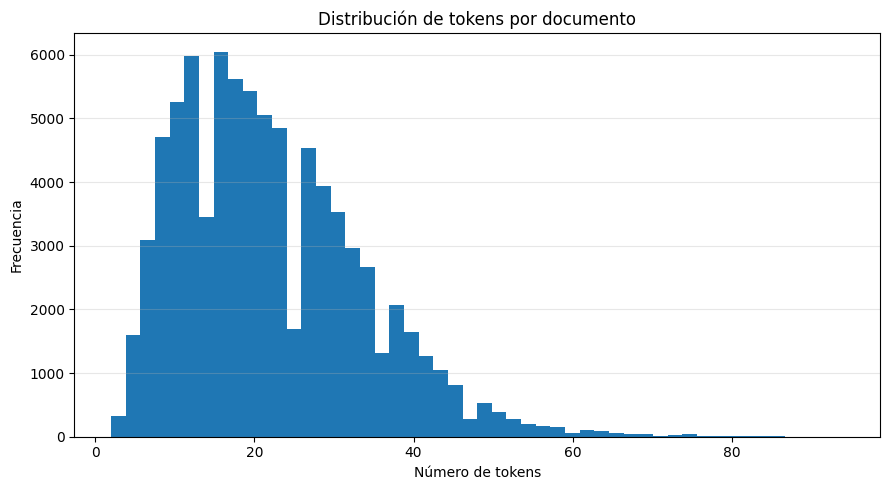

,token,frecuencia
0,mejoramiento,30858
1,san,17812
2,proyecto,16584
3,mantenimiento,13884
4,ejecucion,12864
5,cusco,10252
6,centro,10160
7,creacion,9507
8,adquisici,9182
9,agua,8893


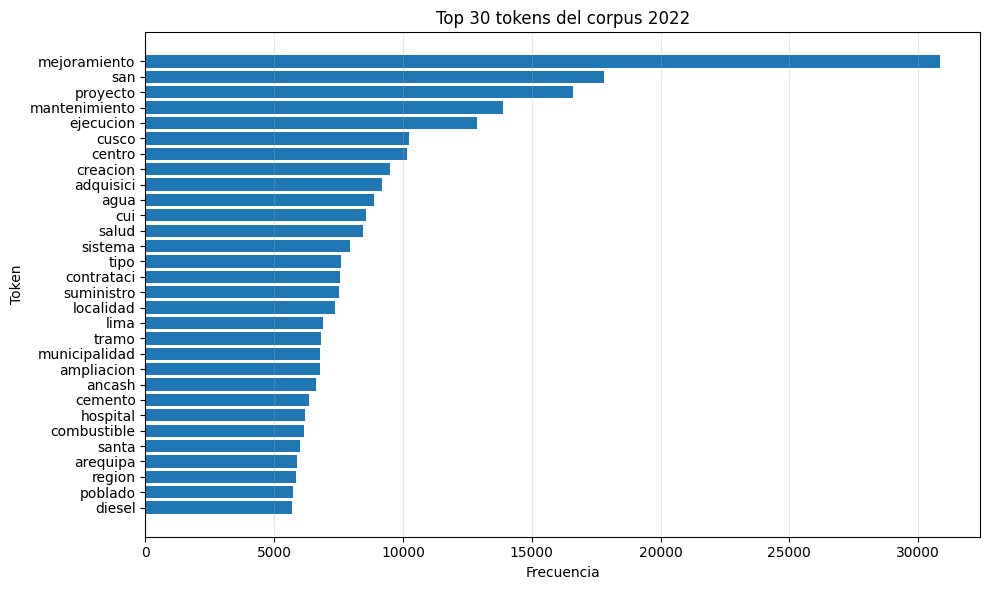

In [11]:
# ============================================================
# EXPLORACIÓN DESCRIPTIVA DEL CORPUS
# ============================================================

resumen_textual = pd.DataFrame([{
    "n_documentos": len(corpus_2022),
    "n_textos_vacios_modelo": int((corpus_2022["texto_modelo"] == "").sum()),
    "promedio_caracteres": corpus_2022["n_caracteres"].mean(),
    "mediana_caracteres": corpus_2022["n_caracteres"].median(),
    "promedio_tokens": corpus_2022["n_tokens"].mean(),
    "mediana_tokens": corpus_2022["n_tokens"].median()
}])

display(resumen_textual.round(2))
resumen_textual.to_csv(RUTA_AUDITORIA / "s5_resumen_textual.csv", index=False, encoding="utf-8")

# Histograma de longitud
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(corpus_2022["n_tokens"], bins=50)
ax.set_title("Distribución de tokens por documento")
ax.set_xlabel("Número de tokens")
ax.set_ylabel("Frecuencia")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
fig.savefig(RUTA_FIGURAS / "s5_histograma_tokens.png", dpi=300, bbox_inches="tight")
plt.show()

# Frecuencias
frecuencias = Counter()
for lista in corpus_2022["tokens"]:
    frecuencias.update(lista)

top_30 = pd.DataFrame(frecuencias.most_common(30), columns=["token", "frecuencia"])
display(top_30)
top_30.to_csv(RUTA_TABLAS / "s5_top_30_tokens.csv", index=False, encoding="utf-8")

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_30["token"][::-1], top_30["frecuencia"][::-1])
ax.set_title("Top 30 tokens del corpus 2022")
ax.set_xlabel("Frecuencia")
ax.set_ylabel("Token")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
fig.savefig(RUTA_FIGURAS / "s5_top_30_tokens.png", dpi=300, bbox_inches="tight")
plt.show()

In [12]:
# ============================================================
# REPRESENTACIÓN TEXTUAL: BoW y TF-IDF
# ============================================================

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

corpus_modelo = corpus_2022.loc[corpus_2022["texto_modelo"] != "", "texto_modelo"].copy()

# BoW
bow_vectorizer = CountVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    min_df=5
)
X_bow = bow_vectorizer.fit_transform(corpus_modelo)

print("BoW shape:", X_bow.shape)

# TF-IDF
tfidf_vectorizer = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    min_df=5
)
X_tfidf = tfidf_vectorizer.fit_transform(corpus_modelo)

print("TF-IDF shape:", X_tfidf.shape)

# Muestra de vocabulario
vocab_bow = pd.DataFrame({"termino": bow_vectorizer.get_feature_names_out()})
vocab_tfidf = pd.DataFrame({"termino": tfidf_vectorizer.get_feature_names_out()})

display(vocab_bow.head(20))
display(vocab_tfidf.head(20))

vocab_bow.to_csv(RUTA_TABLAS / "s5_vocabulario_bow.csv", index=False, encoding="utf-8")
vocab_tfidf.to_csv(RUTA_TABLAS / "s5_vocabulario_tfidf.csv", index=False, encoding="utf-8")

BoW shape: (81400, 3000)
TF-IDF shape: (81400, 3000)


,termino
0,abad
1,abad ucayali
2,abancay
3,abancay abancay
4,abancay apurimac
5,abastecimiento
6,abastecimiento agua
7,abastos
8,abogado
9,abogado tercero


,termino
0,abad
1,abad ucayali
2,abancay
3,abancay abancay
4,abancay apurimac
5,abastecimiento
6,abastecimiento agua
7,abastos
8,abogado
9,abogado tercero


In [13]:
# ============================================================
# TÉRMINOS MÁS INFORMATIVOS SEGÚN TF-IDF
# ============================================================

promedio_tfidf = np.asarray(X_tfidf.mean(axis=0)).ravel()
terminos_tfidf = tfidf_vectorizer.get_feature_names_out()

tabla_tfidf = (
    pd.DataFrame({"termino": terminos_tfidf, "tfidf_promedio": promedio_tfidf})
    .sort_values("tfidf_promedio", ascending=False)
    .reset_index(drop=True)
)

display(tabla_tfidf.head(30))
tabla_tfidf.to_csv(RUTA_TABLAS / "s5_top_tfidf_promedio.csv", index=False, encoding="utf-8")

,termino,tfidf_promedio
0,mejoramiento,0.022327
1,mantenimiento,0.017249
2,san,0.015421
3,proyecto,0.015326
4,adquisici,0.011999
5,cusco,0.011868
6,salud,0.011747
7,ejecucion,0.011697
8,suministro,0.011266
9,centro,0.011232


In [14]:
# ============================================================
# TOPIC MODELING CON NMF
# ============================================================

from sklearn.decomposition import NMF

# Para mantener la sesión ligera y pedagógica, modelamos sobre una muestra reproducible
N_DOCS_MODELO = min(20000, X_tfidf.shape[0])

idx_sample = corpus_modelo.sample(n=N_DOCS_MODELO, random_state=42).index
X_tfidf_sample = tfidf_vectorizer.transform(corpus_modelo.loc[idx_sample])

n_topics = 5
nmf = NMF(n_components=n_topics, random_state=42, init="nndsvda", max_iter=300)
W = nmf.fit_transform(X_tfidf_sample)
H = nmf.components_

terminos = tfidf_vectorizer.get_feature_names_out()

topicos = []
for i, topic in enumerate(H):
    palabras = [terminos[j] for j in topic.argsort()[::-1][:12]]
    topicos.append({
        "topico": f"Topico_{i+1}",
        "palabras_clave": ", ".join(palabras)
    })

tabla_topicos = pd.DataFrame(topicos)
display(tabla_topicos)
tabla_topicos.to_csv(RUTA_MODELOS / "s5_nmf_topicos.csv", index=False, encoding="utf-8")

# Asignar tópico dominante a la muestra
topico_dominante = W.argmax(axis=1) + 1
df_topicos_docs = pd.DataFrame({
    "indice_documento": idx_sample,
    "topico_dominante": topico_dominante
})

df_topicos_docs = df_topicos_docs.merge(
    corpus_2022[["texto_base", "fuente_archivo", "objetocontractual", "tipoprocesoseleccion"]].reset_index(),
    left_on="indice_documento",
    right_on="index",
    how="left"
).drop(columns="index")

display(df_topicos_docs.head(10))
df_topicos_docs.to_csv(RUTA_MODELOS / "s5_nmf_documentos_topico.csv", index=False, encoding="utf-8")

,topico,palabras_clave
0,Topico_1,"cemento, tipo, portland, cemento portland, portland tipo, mejoramiento, proyecto, cusco, san, proyecto mejoramiento, agua, centro"
1,Topico_2,"combustible, diesel, combustible diesel, municipalidad, unidades, suministro, distrital, municipalidad distrital, suministro combustible, gasohol, plus, gasohol plus"
2,Topico_3,"leche, programa, vaso, vaso leche, programa vaso, evaporada, leche evaporada, entera, evaporada entera, municipalidad, insumos, distrital"
3,Topico_4,"mantenimiento, camino, vecinal, camino vecinal, rutinario, tramo, rutinario camino, mantenimiento rutinario, emp, vecinal tramo, vial, mantenimiento vial"
4,Topico_5,"salud, establecimientos, establecimientos salud, productos, meses, productos farmaceuticos, farmaceuticos, doce meses, doce, periodo doce, periodo, essalud"


,indice_documento,topico_dominante,texto_base,fuente_archivo,objetocontractual,tipoprocesoseleccion
0,57578,5,SERVICIO DE LIMPIEZA PARA LA CORTE SUPERIOR DE JUSTICIA DE AMAZONAS || SERVICIO DE LIMPIEZA,todos_los_procesos,Servicio,Concurso Público
1,27457,1,"EJECUCION DE OBRA: AMPLIACION DE LA LINEA DE CONDUCCIÓN DEL SISTEMA DE AGUA POTABLE EN EL SECTOR TUMARIN C.P. PARIACANCHA DEL DISTRITO DE UCO - PROVINCIA DE HUARI - DEPARTAMENTO DE ANCASH, CON C.U...",todos_los_procesos,Obra,Adjudicación Simplificada
2,47571,5,"ADQUISICIÓN DE VÍVERES SECOS, FRESCOS, VERDURAS Y TUBÉRCULOS PARA EL RACIONAMIENTO DEL PERSONAL NAVAL, PERIODO ANUAL /BIEN PP 00135 || HARINA DE TRIGO",todos_los_procesos,Bien,Subasta Inversa Electrónica
3,9023,5,CONTRATACIÓN DE SUMINISTRO DE LIBRETAS DE PASAPORTE ELECTRÓNICO Y LÁMINAS DE SEGURIDAD || CONTRATACI¿N DEL SUMINISTRO DE LIBRETAS DE PASAPORTE ELECTR¿NICO Y L¿MINAS DE SEGURIDAD,todos_los_procesos,Bien,Convenio
4,37447,1,"ADQUISICIÓN DE TERRENO, DEL PROYECTO IOARR: ""ADQUISICIÓN DE TERRENO, SANEAMIENTO TECNICO LEGAL DE TERRENO; EN EL (LA) TERMINAL TERRESTRE EN LA LOCALIDAD DE PICHARI, DEL DISTRITO PICHARI, LA CONVEN...",todos_los_procesos,Bien,Contratación Directa
5,23919,1,SERVICIO DE ALQUILER DE MINICARGADOR DE 50 HP A MAS MAQUINA SECA INCLUYE OPERADOR PARA EL PARA EL MEJORAMIENTO DE VIAS Y CONSTRUCCION DE VEREDAS EN LAS JUNTAS VECINALES VILLA LOS ANGELES Y LOS ANG...,todos_los_procesos,Servicio,Comparación de Precios
6,15781,4,"EJECUCION DE OBRA: ¿RENOVACION DE PUENTE; EN EL (LA) CAMINO VECINAL RUTA Nº AN-1238, TRAYECTORIA: EMP. AN-1236- CUYHUAN-RUINAS ARQUEOLOGICAS-HUANCAHUASI-CHURAP (PUENTE HUACUY) LOCALIDAD DE MARCA, ...",todos_los_procesos,Obra,Adjudicación Simplificada
7,8875,4,ADQUISICION DE 02 EQUIPOS DE RAYOS X DENTAL DEL IOARR N° CUI-2532612 POR REPOSICION PARA EL HOSPITAL SAN JUAN DE DIOS DE PISCO || EQUIPO DE RAYOS X DENTAL,todos_los_procesos,Bien,Comparación de Precios
8,80276,5,"Contratación de Dispositivos Médicos para los Establecimientos de Salud de EsSalud, por un período de dos (02) meses- Material Médico- 02 Ítems. || MAMELUCO DESCARTABLE M",solo_cd,Bien,Contratación Directa
9,62716,4,"CONTRATACION DE SUPERVISION DE LA EJECUCION DE OBRA DEL PROYECTO: ""CONSTRUCCIÓN DE COLECTOR SECUNDARIO Y RED DE DISTRIBUCION; EN EL (LA) AV. FERROCARRIL TRAMO PROLOG. ICA Y CALLE REAL DISTRITO DE ...",todos_los_procesos,Consultoría de Obra,Adjudicación Simplificada


In [15]:
# ============================================================
# CLUSTERING CON K-MEANS
# ============================================================

from sklearn.cluster import KMeans

n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
clusters = kmeans.fit_predict(X_tfidf_sample)

df_clusters = pd.DataFrame({
    "indice_documento": idx_sample,
    "cluster": clusters
})

df_clusters = df_clusters.merge(
    corpus_2022[["texto_base", "fuente_archivo", "objetocontractual", "tipoprocesoseleccion"]].reset_index(),
    left_on="indice_documento",
    right_on="index",
    how="left"
).drop(columns="index")

display(df_clusters.head(10))

resumen_clusters = (
    df_clusters.groupby("cluster", as_index=False)
    .agg(
        n_documentos=("cluster", "count")
    )
    .sort_values("n_documentos", ascending=False)
)

display(resumen_clusters)
resumen_clusters.to_csv(RUTA_MODELOS / "s5_resumen_clusters.csv", index=False, encoding="utf-8")
df_clusters.to_csv(RUTA_MODELOS / "s5_documentos_clusters.csv", index=False, encoding="utf-8")

,indice_documento,cluster,texto_base,fuente_archivo,objetocontractual,tipoprocesoseleccion
0,57578,2,SERVICIO DE LIMPIEZA PARA LA CORTE SUPERIOR DE JUSTICIA DE AMAZONAS || SERVICIO DE LIMPIEZA,todos_los_procesos,Servicio,Concurso Público
1,27457,3,"EJECUCION DE OBRA: AMPLIACION DE LA LINEA DE CONDUCCIÓN DEL SISTEMA DE AGUA POTABLE EN EL SECTOR TUMARIN C.P. PARIACANCHA DEL DISTRITO DE UCO - PROVINCIA DE HUARI - DEPARTAMENTO DE ANCASH, CON C.U...",todos_los_procesos,Obra,Adjudicación Simplificada
2,47571,2,"ADQUISICIÓN DE VÍVERES SECOS, FRESCOS, VERDURAS Y TUBÉRCULOS PARA EL RACIONAMIENTO DEL PERSONAL NAVAL, PERIODO ANUAL /BIEN PP 00135 || HARINA DE TRIGO",todos_los_procesos,Bien,Subasta Inversa Electrónica
3,9023,2,CONTRATACIÓN DE SUMINISTRO DE LIBRETAS DE PASAPORTE ELECTRÓNICO Y LÁMINAS DE SEGURIDAD || CONTRATACI¿N DEL SUMINISTRO DE LIBRETAS DE PASAPORTE ELECTR¿NICO Y L¿MINAS DE SEGURIDAD,todos_los_procesos,Bien,Convenio
4,37447,3,"ADQUISICIÓN DE TERRENO, DEL PROYECTO IOARR: ""ADQUISICIÓN DE TERRENO, SANEAMIENTO TECNICO LEGAL DE TERRENO; EN EL (LA) TERMINAL TERRESTRE EN LA LOCALIDAD DE PICHARI, DEL DISTRITO PICHARI, LA CONVEN...",todos_los_procesos,Bien,Contratación Directa
5,23919,3,SERVICIO DE ALQUILER DE MINICARGADOR DE 50 HP A MAS MAQUINA SECA INCLUYE OPERADOR PARA EL PARA EL MEJORAMIENTO DE VIAS Y CONSTRUCCION DE VEREDAS EN LAS JUNTAS VECINALES VILLA LOS ANGELES Y LOS ANG...,todos_los_procesos,Servicio,Comparación de Precios
6,15781,3,"EJECUCION DE OBRA: ¿RENOVACION DE PUENTE; EN EL (LA) CAMINO VECINAL RUTA Nº AN-1238, TRAYECTORIA: EMP. AN-1236- CUYHUAN-RUINAS ARQUEOLOGICAS-HUANCAHUASI-CHURAP (PUENTE HUACUY) LOCALIDAD DE MARCA, ...",todos_los_procesos,Obra,Adjudicación Simplificada
7,8875,2,ADQUISICION DE 02 EQUIPOS DE RAYOS X DENTAL DEL IOARR N° CUI-2532612 POR REPOSICION PARA EL HOSPITAL SAN JUAN DE DIOS DE PISCO || EQUIPO DE RAYOS X DENTAL,todos_los_procesos,Bien,Comparación de Precios
8,80276,2,"Contratación de Dispositivos Médicos para los Establecimientos de Salud de EsSalud, por un período de dos (02) meses- Material Médico- 02 Ítems. || MAMELUCO DESCARTABLE M",solo_cd,Bien,Contratación Directa
9,62716,3,"CONTRATACION DE SUPERVISION DE LA EJECUCION DE OBRA DEL PROYECTO: ""CONSTRUCCIÓN DE COLECTOR SECUNDARIO Y RED DE DISTRIBUCION; EN EL (LA) AV. FERROCARRIL TRAMO PROLOG. ICA Y CALLE REAL DISTRITO DE ...",todos_los_procesos,Consultoría de Obra,Adjudicación Simplificada


,cluster,n_documentos
2,2,10866
3,3,6562
4,4,1474
1,1,717
0,0,381


In [16]:
# ============================================================
# SIMILARIDAD TEXTUAL
# ============================================================

from sklearn.metrics.pairwise import cosine_similarity

# Muestra reducida para demostrar similaridad
muestra_sim = corpus_2022.loc[corpus_2022["texto_modelo"] != "", ["texto_base", "texto_modelo"]].sample(n=1000, random_state=42).reset_index(drop=True)

vectorizer_sim = TfidfVectorizer(max_features=2000, min_df=3)
X_sim = vectorizer_sim.fit_transform(muestra_sim["texto_modelo"])

sim_matrix = cosine_similarity(X_sim)

def documentos_mas_parecidos(indice_doc, top_n=5):
    sims = sim_matrix[indice_doc]
    orden = sims.argsort()[::-1]
    orden = [i for i in orden if i != indice_doc][:top_n]
    return pd.DataFrame({
        "indice_referencia": indice_doc,
        "indice_comparado": orden,
        "similaridad": [sims[i] for i in orden],
        "texto_referencia": [muestra_sim.loc[indice_doc, "texto_base"]] * len(orden),
        "texto_comparado": [muestra_sim.loc[i, "texto_base"] for i in orden]
    })

tabla_sim = documentos_mas_parecidos(0, top_n=5)
display(tabla_sim)
tabla_sim.to_csv(RUTA_MODELOS / "s5_similaridad_ejemplo.csv", index=False, encoding="utf-8")

,indice_referencia,indice_comparado,similaridad,texto_referencia,texto_comparado
0,0,934,0.557588,SERVICIO DE LIMPIEZA PARA LA CORTE SUPERIOR DE JUSTICIA DE AMAZONAS || SERVICIO DE LIMPIEZA,CONTRATACION DEL SERVICIO PROFESIONAL EN SALUD OCUPACIONAL PARA LA CORTE SUPERIOR DE JUSTICIA DE CAÑETE || SERVICIO DE ENFERMERIA OCUPACIONAL PARA LA CORTE SUPERIOR DE JUSTICIA DE CA¿ETE
1,0,379,0.463992,SERVICIO DE LIMPIEZA PARA LA CORTE SUPERIOR DE JUSTICIA DE AMAZONAS || SERVICIO DE LIMPIEZA,SERVICIO DE LIMPIEZA DE RESIDUOS Y SEDIMENTOS DEL EMBALSE Y NAVES DEL DESARENADOR DE PRESA TABLACHACA PROCESO DE PURGA AÑO 2023 || SERVICIO DE LIMPIEZA DE RESIDUOS Y SEDIMENTOS DEL EMBALSE Y NAVES...
2,0,356,0.383483,SERVICIO DE LIMPIEZA PARA LA CORTE SUPERIOR DE JUSTICIA DE AMAZONAS || SERVICIO DE LIMPIEZA,ADQUISICION DE MATERIALES DE ASEO Y LIMPIEZA || ITEM PAQUETE VII: TOALLA HIGIENICA
3,0,351,0.368195,SERVICIO DE LIMPIEZA PARA LA CORTE SUPERIOR DE JUSTICIA DE AMAZONAS || SERVICIO DE LIMPIEZA,ARRENDAMIENTO DE INMUEBLE PARA EL FUNCIONAMIENTO DE LOS JUZGADOS DE CERRO COLORADO DEL NCPP DE LA CORTE SUPERIOR DE JUSTICIA DE AREQUIPA || ARRENDAMIENTO DE INMUEBLE PARA EL FUNCIONAMIENTO DE LOS ...
4,0,101,0.356435,SERVICIO DE LIMPIEZA PARA LA CORTE SUPERIOR DE JUSTICIA DE AMAZONAS || SERVICIO DE LIMPIEZA,ADQUISICIÓN DE LECHE EN TETRAPACK PARA EL PERSONAL DE ARCHIVOS DE LA CORTE SUPERIOR DE JUSTICIA DE LAMBAYEQUE || ADQUISIC¿N DE LECHE EN TETRAPACK PARA EL PERSONAL DE ARCHIVOS DE LA CSJLA


In [17]:
# ============================================================
# OPCIONAL — INSTALACIÓN DE TRANSFORMERS
# ============================================================

!pip -q install transformers sentencepiece accelerate

In [18]:
# ============================================================
# OPCIONAL — FILL MASK
# ============================================================

from transformers import pipeline

unmasker = pipeline("fill-mask", model="FacebookAI/roberta-base")

ejemplos_mask = [
    "Public procurement requires strong <mask>.",
    "La contratacion publica necesita mayor <mask>.",
    "The entity published the <mask>."
]

for e in ejemplos_mask:
    print("\nTexto:", e)
    print(unmasker(e))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

RobertaForMaskedLM LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


Texto: Public procurement requires strong <mask>.
[{'score': 0.08708611130714417, 'token': 9233, 'token_str': ' oversight', 'sequence': 'Public procurement requires strong oversight.'}, {'score': 0.07041775435209274, 'token': 25563, 'token_str': ' safeguards', 'sequence': 'Public procurement requires strong safeguards.'}, {'score': 0.06781988590955734, 'token': 3353, 'token_str': ' institutions', 'sequence': 'Public procurement requires strong institutions.'}, {'score': 0.05881514772772789, 'token': 7166, 'token_str': ' governance', 'sequence': 'Public procurement requires strong governance.'}, {'score': 0.05001211538910866, 'token': 1673, 'token_str': ' leadership', 'sequence': 'Public procurement requires strong leadership.'}]

Texto: La contratacion publica necesita mayor <mask>.
[{'score': 0.26193591952323914, 'token': 19689, 'token_str': 'ismo', 'sequence': 'La contratacion publica necesita mayorismo.'}, {'score': 0.21742188930511475, 'token': 14369, 'token_str': 'itar', 'sequenc

In [19]:
# ============================================================
# OPCIONAL — SENTIMENT ANALYSIS
# ============================================================

from transformers import pipeline

modelo_sentimiento = pipeline(
    model="lxyuan/distilbert-base-multilingual-cased-sentiments-student",
    top_k=None
)

ejemplos_sentimiento = [
    "La plataforma es clara y ordenada.",
    "El procedimiento fue confuso y lento.",
    "La descripcion del proceso es bastante tecnica.",
    "The system works well and the data is useful."
]

for texto in ejemplos_sentimiento:
    print("\nTexto:", texto)
    print(modelo_sentimiento(texto))

config.json:   0%|          | 0.00/759 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/541M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/373 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]


Texto: La plataforma es clara y ordenada.
[[{'label': 'positive', 'score': 0.4353658854961395}, {'label': 'neutral', 'score': 0.4040827751159668}, {'label': 'negative', 'score': 0.16055133938789368}]]

Texto: El procedimiento fue confuso y lento.
[[{'label': 'positive', 'score': 0.5065069794654846}, {'label': 'negative', 'score': 0.33132404088974}, {'label': 'neutral', 'score': 0.16216889023780823}]]

Texto: La descripcion del proceso es bastante tecnica.
[[{'label': 'positive', 'score': 0.4947024881839752}, {'label': 'neutral', 'score': 0.28519731760025024}, {'label': 'negative', 'score': 0.22010013461112976}]]

Texto: The system works well and the data is useful.
[[{'label': 'positive', 'score': 0.8913623094558716}, {'label': 'neutral', 'score': 0.0830085277557373}, {'label': 'negative', 'score': 0.025629205629229546}]]


In [21]:
# ============================================================
# CIERRE Y RESUMEN DE EXPORTACIONES
# ============================================================

resumen_exportaciones = pd.DataFrame({
    "carpeta": ["auditoria", "tablas", "figuras", "modelos"],
    "ruta": [
        str(RUTA_AUDITORIA),
        str(RUTA_TABLAS),
        str(RUTA_FIGURAS),
        str(RUTA_MODELOS)
    ]
})

display(resumen_exportaciones)

resumen_exportaciones.to_csv(RUTA_RESULTADOS / "s5_resumen_exportaciones.csv", index=False, encoding="utf-8")

print("Sesión 5 mejorada ejecutada correctamente.")
print("Resultados principales guardados en:", RUTA_RESULTADOS)

,carpeta,ruta
0,auditoria,/content/drive/MyDrive/IA Generativa para CCSS/Base de datos/Resultados/Sesion_5_NLP_mejorada/auditoria
1,tablas,/content/drive/MyDrive/IA Generativa para CCSS/Base de datos/Resultados/Sesion_5_NLP_mejorada/tablas
2,figuras,/content/drive/MyDrive/IA Generativa para CCSS/Base de datos/Resultados/Sesion_5_NLP_mejorada/figuras
3,modelos,/content/drive/MyDrive/IA Generativa para CCSS/Base de datos/Resultados/Sesion_5_NLP_mejorada/modelos


Sesión 5 mejorada ejecutada correctamente.
Resultados principales guardados en: /content/drive/MyDrive/IA Generativa para CCSS/Base de datos/Resultados/Sesion_5_NLP_mejorada


## Cierre metodológico de la sesión 5

La sesión 5 mostró que el NLP no debe entenderse únicamente como una serie de técnicas abstractas sobre texto, sino como un conjunto de procedimientos para transformar descripciones verbales en objetos analíticos computables En esta versión mejorada, la sesión dejó de apoyarse solo en ejemplos pequeños y pasó a trabajar con un corpus administrativo real: las convocatorias 2022 del portal CONOSCE/OECE. Esto permitió:

- auditar archivos reales,
- leer un diccionario de datos institucional,
- construir un corpus textual reproducible,
- limpiar y representar textos en español,
- extraer vocabulario relevante,
- identificar tópicos,
- agrupar documentos,
- y medir similaridad textual.

Con ello, la sesión ya no es solo una introducción general al NLP, sino una preparación concreta para aplicar estas herramientas a textos de contrataciones públicas, lo que servirá de base para la adaptación posterior al proyecto de la Tarea 2.